# Cambios del Script $22/06/26$
- ### Se agrega un Ansatz con la condicion inicial
- ### Dado el Ansatz se quita $Loss_{ic}$
- ### Cinco Capas ocultas con 72 neuronas y SWISH cada una  

In [1]:
# ============================================================
# PINN para lahar por etapas (z_b fijo, sin Exner)
# Aprende: h, u, v, C, p
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, optimizers #type: ignore
import matplotlib.pyplot as plt
tf.random.set_seed(7)
np.random.seed(7)

2026-09-28 23:45:09.837924: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-28 23:45:11.158294: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/djara/miniconda3/envs/tf216/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# ============================================================
# SELECCIÓN DE TOPOGRAFÍA
# ============================================================
TOPO_SCENARIO = 2 # 1: plano inclinado, 2: valle gaussiano, 3: canal sinuoso
# ============================================================
# 1) PARÁMETROS FÍSICOS
# ============================================================
g = 9.81
rho_m = 1800.0
mu0 = 0.20
alpha_C = 1.2
alpha_p = 4.0
C0 = 0.45
p_ref = 1e4
kappa_C = 0.0 #5.0
tau_C = 1e9 # relajación casi nula para C
tau_p = 120.0
chi_p = 0.8 #0.35
# lambda = p/(rho_m g h) inicial. Con mu0=0.2 y pendiente 8% el lahar necesita
# lambda > ~0.29 para que mu_eff < tan(theta); con 0.2 quedaba bloqueado.
lambda_0 = 0.60
# Piso hidrostático: un lahar está SATURADO en agua, así que su presión de poros
# basal nunca baja de la del fluido intersticial, p >= rho_f g h (Iverson 1997).
# En lambda: lambda >= rho_f/rho_m ~ 0.556. Con este piso mu_eff <~ 0.03 < tan(theta)
# en el cuerpo del lahar: el estado "detenido" deja de ser solución de las EDP.
rho_f = 1000.0                   # densidad del fluido intersticial [kg/m3]
lambda_hydro = rho_f / rho_m     # ~0.556
assert lambda_0 >= lambda_hydro, "lambda_0 no puede ser menor que el piso hidrostático"
# Pared impermeable aguas arriba (x = 0): u = 0 exacto -> no entra masa desde fuera
ell_wall = 250.0                 # [m] longitud de la función distancia
# Rampa temporal del ansatz: omega = 1 - exp(-t/t_ramp). Antes era T/5 = 240 s,
# más lenta que la relajación de p (tau_p = 120 s): la red no alcanzaba a acelerar.
t_ramp = 20.0        # [s]
# Resistencia turbulenta de Voellmy: g|u|u/(xi h). Sin ella, con mu_eff < tan(theta)
# el flujo acelera sin límite (a = g(sin - mu cos) = cte).
xi_voellmy = 500.0   # [m/s2]
h_dry = 0.05         # [m] regularización de 1/h en zona seca
# Restricción integral de volumen: V(t) + (volumen que salió por x = Lx) = V0
lambda_vol = 1.0e4
S_ref = 0.08         # pendiente característica del valle
# Currículo temporal: el horizonte de entrenamiento crece de T_curr0 a Tmax en la etapa 2.
# Primero la red aprende el ARRANQUE (aceleración) y luego lo prolonga en el tiempo.
T_curr0 = 60.0       # [s]
t_early = 120.0      # [s] ventana de arranque sobre-muestreada (25% de cada batch)
u_star = 1.0
C_star = 0.05
eps_u = 1e-3
eps_h = 1e-6
# ============================================================
# 2) DOMINIO
# ============================================================
Lx = 10_000.0
Ly = 2_000.0
Tmax = 1200.0
x_min, x_max = 0.0, Lx
y_min, y_max = -Ly/2, Ly/2
t_min, t_max = 0.0, Tmax
# Normalización
x_scale = Lx
y_scale = Ly/2
t_scale = Tmax
h_scale = 10.0
u_scale = 10.0
p_scale = rho_m * g * h_scale

In [3]:
# ============================================================
# 3) TOPOGRAFÍA FIJA z_b(x,y)
# ============================================================
def zb0_physical(x, y):
    if TOPO_SCENARIO == 1:
        # Plano inclinado (Pendiente 10%) - Usar solo para calibrar
        Sx = 0.10
        z0 = 3000.0
        return z0 - Sx * x

    elif TOPO_SCENARIO == 2:
        # Valle Parabólico Suave (Aproximación Villarrica / Quebrada)
        Sx = 0.08         # Pendiente longitudinal (8%)
        z0 = 2900.0       # Altitud base
        
        # Curvatura del valle. 
        # A y=1000m, las paredes suben 50 metros respecto al centro.
        # Esto confina el flujo sin generar gradientes explosivos.
        k_y = 50.0 / (1000.0**2) 
        
        return (z0 - Sx * x) + k_y * (y**2)

    else:
        # Valle Convergente (Embudamiento)
        # El canal se hace más estrecho a medida que se desciende
        Sx = 0.08
        z0 = 2900.0
        # La pendiente transversal aumenta linealmente con 'x'
        k_y = (20.0 + 0.01 * x) / (1000.0**2) 
        return (z0 - Sx * x) + k_y * (y**2)

def grad_zb_fixed(x, y):
    """
    Gradiente de la topografía fija.
    Se calcula aparte para evitar NoneType en Graph mode.
    """
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([x, y])
        zb = zb0_physical(x, y)
    zb_x = tape.gradient(zb, x)
    zb_y = tape.gradient(zb, y)
    del tape
    return zb_x, zb_y

# ============================================================
# 4) CONDICIONES INICIALES
# ============================================================
def ic_h_physical(x, y):
    x0, y0 = 1200.0, 0.0
    sigx, sigy = 900.0, 450.0
    h0 = 8.0
    return h0 * tf.exp(-((x - x0)**2 / (2 * sigx**2) + (y - y0)**2 / (2 * sigy**2)))

def ic_u_physical(x, y):
    return tf.zeros_like(x)

def ic_v_physical(x, y):
    return tf.zeros_like(y)

def ic_C_physical(x, y):
    C_bg = 0.35 #Minimo
    C_peak = 0.25
    x0, y0 = 1200.0, 0.0
    sigx, sigy = 1000.0, 550.0
    C = C_bg + C_peak * tf.exp(-((x - x0)**2 / (2 * sigx**2) + (y - y0)**2 / (2 * sigy**2)))
    return tf.clip_by_value(C, 0.2, 0.75)

def ic_p_physical(x, y):
    return lambda_0 * rho_m * g * ic_h_physical(x, y)


# ============================================================
# 5) MUESTREO DE PUNTOS
# ============================================================
N_ic = 4000
N_pde = 30000
N_bc = 4000

# IC (t=0)
x_ic = tf.random.uniform((N_ic, 1), x_min, x_max, dtype=tf.float32)
y_ic = tf.random.uniform((N_ic, 1), y_min, y_max, dtype=tf.float32)
t_ic = tf.zeros_like(x_ic)

h_ic = ic_h_physical(x_ic, y_ic)
u_ic = ic_u_physical(x_ic, y_ic)
v_ic = ic_v_physical(x_ic, y_ic)
C_ic = ic_C_physical(x_ic, y_ic)
p_ic = ic_p_physical(x_ic, y_ic)

# PDE collocation
# Los puntos PDE se muestrean NUEVOS en cada paso (celda 7, sample_pde_batch):
# horizonte temporal creciente (currículo) + 25% en el arranque [0, t_early].

# BC laterales
x_bc = tf.random.uniform((N_bc, 1), x_min, x_max, dtype=tf.float32)
t_bc = tf.random.uniform((N_bc, 1), t_min, t_max, dtype=tf.float32)
y_bc_top = tf.ones_like(x_bc) * y_max
y_bc_bot = tf.ones_like(x_bc) * y_min

y_bc = tf.random.uniform((N_bc, 1), y_min, y_max, dtype=tf.float32)
t_bc_x = tf.random.uniform((N_bc, 1), t_min, t_max, dtype=tf.float32)
x_bc_left  = tf.ones_like(y_bc) * x_min
x_bc_right = tf.ones_like(y_bc) * x_max

2026-09-28 23:45:17.393279: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-28 23:45:17.897194: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-28 23:45:17.897234: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-28 23:45:17.899467: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-28 23:45:17.899516: I external/local_xla/xla/stream_executor

In [4]:
# ============================================================
# 6) RED NEURONAL: (x,y,t) -> (h,u,v,C) (CON ANSATZ EXACTO)
# ============================================================
Cmax = 0.65

inputs = tf.keras.Input(shape=(3,))
x = layers.Dense(72, activation='swish')(inputs)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
out_raw = layers.Dense(5, activation='linear')(x)

model = tf.keras.Model(inputs=inputs, outputs=out_raw)

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=3000,      
    decay_rate=0.85,        
    staircase=False
)
opt = tf.keras.mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0))

@tf.function
def predict_fields(xm, ym, tm):
    xn = xm / x_scale
    yn = ym / y_scale
    tn = tm / t_scale
    inp = tf.concat([xn, yn, tn], axis=1)
    raw = model(inp)

    h_raw = raw[:, 0:1]
    u_raw = raw[:, 1:2]
    v_raw = raw[:, 2:3]
    C_raw = raw[:, 3:4]
    p_raw = raw[:, 4:5]

    h0 = ic_h_physical(xm, ym)
    u0 = ic_u_physical(xm, ym)
    v0 = ic_v_physical(xm, ym)
    p0 = ic_p_physical(xm, ym)
    C0_ic = ic_C_physical(xm, ym)

    omega = 1.0 - tf.exp(-tm / t_ramp)

    # Pared impermeable en x = 0: d(x) = 1 - exp(-x/ell) vale 0 en x = 0 -> flujo h*u = 0
    wall_x = 1.0 - tf.exp(-xm / ell_wall)
    u = u0 + omega * wall_x * (u_raw * u_scale)
    v = v0 + omega * (v_raw * u_scale)

    # Blindaje h: Evitar log(0)
    clip_h = tf.clip_by_value(1.0 - tf.exp(-h0), 1e-7, 1.0)
    inv_sp_h0 = h0 + tf.math.log(clip_h)
    h = tf.nn.softplus(inv_sp_h0 + omega * h_raw * h_scale)

    # p = p_hidrostática(h) + p_exceso, con p_exceso >= 0 (mismo ansatz que h).
    # En t=0: p = rho_f g h0 + (p0 - rho_f g h0) = p0 exacto. Sin techo litostático.
    p_hydro = rho_f * g * h
    pex0_n = (p0 - rho_f * g * h0) / p_scale
    clip_p = tf.clip_by_value(1.0 - tf.exp(-pex0_n), 1e-7, 1.0)
    inv_sp_p0 = pex0_n + tf.math.log(clip_p)
    p = p_hydro + p_scale * tf.nn.softplus(inv_sp_p0 + omega * p_raw)   # Pa

    # Blindaje C: Evitar log(0) con clip_by_value
    C0_norm = tf.clip_by_value(C0_ic / Cmax, 1e-7, 1.0 - 1e-7)
    inv_sig_C0 = tf.math.log(C0_norm / (1.0 - C0_norm))
    C = Cmax * tf.math.sigmoid(inv_sig_C0 + omega * C_raw)

    return h, u, v, C, p

In [5]:
# ============================================================
# 7) CIERRES FÍSICOS
# ============================================================
@tf.function
def mu_eff(C, p, h):
    denom = rho_m*g*h + p_ref
    return mu0*(1.0 + alpha_C*(C - C0)) * tf.exp(-alpha_p * (p/denom))

@tf.function
def cos_theta(zb_x, zb_y):
    return 1.0 / tf.sqrt(1.0 + zb_x**2 + zb_y**2)

@tf.function
def p_eq(h, C, u, v):
    speed = tf.sqrt(u**2 + v**2 + eps_u)
    phiC = C / (C + C_star)
    # En reposo p relaja a la hidrostática (no a cero); el corte genera exceso de presión.
    # lambda_eq va de rho_f/rho_m ~ 0.56 (reposo) a ~0.56 + chi_p*0.44*phiC ~ 0.88 (flujo rápido)
    p_hydro = rho_f * g * h
    p_excess = chi_p * (rho_m - rho_f) * g * h * phiC * (speed / (speed + u_star))
    return p_hydro + p_excess

# ============================================================
# 8) RESIDUOS PDE (SIN Exner, z_b FIJO)
# ============================================================
@tf.function
def pde_residuals(xm, ym, tm):
    # Primer y segundo orden para h,u,v,C,p
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([xm, ym, tm])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([xm, ym, tm])

            h, u, v, C, p = predict_fields(xm, ym, tm)
            zb = zb0_physical(xm, ym)
            H = h + zb
            hu = h * u
            hv = h * v

        # 1er orden
        h_t = tape1.gradient(h, tm)
        hu_x = tape1.gradient(hu, xm)
        hv_y = tape1.gradient(hv, ym)

        u_t = tape1.gradient(u, tm)
        u_x = tape1.gradient(u, xm)
        u_y = tape1.gradient(u, ym)

        v_t = tape1.gradient(v, tm)
        v_x = tape1.gradient(v, xm)
        v_y = tape1.gradient(v, ym)

        H_x = tape1.gradient(H, xm)
        H_y = tape1.gradient(H, ym)

        C_t = tape1.gradient(C, tm)
        C_x = tape1.gradient(C, xm)
        C_y = tape1.gradient(C, ym)

        p_t = tape1.gradient(p, tm)
        p_x = tape1.gradient(p, xm)
        p_y = tape1.gradient(p, ym)

    # 2do orden
    C_xx = tape2.gradient(C_x, xm)
    C_yy = tape2.gradient(C_y, ym)

    del tape1
    del tape2

    # Gradiente topografía fija (separado)
    zb_x, zb_y = grad_zb_fixed(xm, ym)

    # Seguridad extra por si alguna derivada sale None
    if C_xx is None:
        C_xx = tf.zeros_like(xm)
    if C_yy is None:
        C_yy = tf.zeros_like(ym)
    if zb_x is None:
        zb_x = tf.zeros_like(xm)
    if zb_y is None:
        zb_y = tf.zeros_like(ym)

    # (1) Masa
    S_h = 0.0
    f_mass = h_t + hu_x + hv_y - S_h

    # Fricción basal
    speed = tf.sqrt(u**2 + v**2 + eps_u)
    mu = mu_eff(C, p, h)
    cth = cos_theta(zb_x, zb_y)

    tau_b = mu * rho_m * g * h * cth
    tau_bx = tau_b * (u / (speed + eps_u))
    tau_by = tau_b * (v / (speed + eps_u))

    # Resistencia turbulenta de Voellmy (aceleración)
    turb_x = g * speed * u / (xi_voellmy * (h + h_dry))
    turb_y = g * speed * v / (xi_voellmy * (h + h_dry))

    # (2) Momento x
    f_momx = u_t + u * u_x + v * u_y + g * H_x + tau_bx / (rho_m * (h + eps_h)) + turb_x

    # (3) Momento y
    f_momy = v_t + u * v_x + v * v_y + g * H_y + tau_by / (rho_m * (h + eps_h)) + turb_y

    # (4) Concentración
    C_eq_val = 0.45
    f_C = C_t + u * C_x + v * C_y - (kappa_C * (C_xx + C_yy) + (C_eq_val - C) / tau_C)
    
    # (5) Presión de poros (advección + relajación)
    peq = p_eq(h, C, u, v)
    f_p = p_t + u*p_x + v*p_y - (peq - p)/tau_p


    return f_mass, f_momx, f_momy, f_C, f_p



In [6]:
# ============================================================
# 9) PÉRDIDAS
# ============================================================
# ============================================================
# PÉRDIDA DE FRONTERA (NEUMANN / OPEN BOUNDARY)
# ============================================================

@tf.function
def neumann_C_residual(xb, yb, tb, direction):
    with tf.GradientTape() as tape:
        if direction == 'y':
            tape.watch(yb); _, _, _, C, _ = predict_fields(xb, yb, tb)  # FIX: C es el 4o, no el 5o
            dC_dn = tape.gradient(C, yb)
        else:
            tape.watch(xb); _, _, _, C, _ = predict_fields(xb, yb, tb)  # FIX: C es el 4o, no el 5o
            dC_dn = tape.gradient(C, xb)
    return dC_dn

@tf.function
def loss_bc():
    # --- h: Dirichlet en paredes laterales (igual que antes) ---
    h_top, _, _, _, _ = predict_fields(x_bc, y_bc_top, t_bc)
    h_bot, _, _, _, _ = predict_fields(x_bc, y_bc_bot, t_bc)

    eps = 1e-8
    loss_h_top = tf.reduce_mean(tf.square((h_top - 0.0) / (h_scale + eps)))
    loss_h_bot = tf.reduce_mean(tf.square((h_bot - 0.0) / (h_scale + eps)))

    # --- CORRECCIÓN: C con Neumann homogéneo en LAS 4 FRONTERAS ---
    # Paredes laterales del valle (y = y_min, y_max)
    dC_dy_top = neumann_C_residual(x_bc, y_bc_top, t_bc, 'y')
    dC_dy_bot = neumann_C_residual(x_bc, y_bc_bot, t_bc, 'y')
    # Entrada / salida longitudinal (x = x_min, x_max)
    dC_dx_left  = neumann_C_residual(x_bc_left,  y_bc, t_bc_x, 'x')
    dC_dx_right = neumann_C_residual(x_bc_right, y_bc, t_bc_x, 'x')

    # Escalas para adimensionalizar cada residuo de flujo (misma lógica
    # que scale_mass, scale_mom, scale_C en loss_pde_stage2). Se usa una
    # escala distinta para x e y porque Lx >> Ly y de lo contrario el
    # término en x quedaría sub-penalizado solo por la diferencia de escala
    # geométrica, no por ser realmente más preciso.
    scale_C_y = Cmax / y_scale
    scale_C_x = Cmax / x_scale


    return loss_h_top + loss_h_bot

@tf.function
def loss_pde_stage2(xb, yb, tb):
    f_mass, f_momx, f_momy, f_C, f_p = pde_residuals(xb, yb, tb)
    eps = 1e-8
    scale_mass = h_scale / t_scale
    # Momento: 10x la escala original u_scale/t_scale. Con la original la red violaba la
    # conservación de volumen (~90%); con g*S (80x) prefería no acelerar.
    scale_mom = 0.1 * g * S_ref
    scale_C = Cmax / t_scale
    scale_p = p_scale / t_scale
    
    return (
        tf.reduce_mean(tf.square(f_mass / (scale_mass + eps))) +
        tf.reduce_mean(tf.square(f_momx / (scale_mom + eps))) +
        tf.reduce_mean(tf.square(f_momy / (scale_mom + eps))) +
        tf.reduce_mean(tf.square(f_C / (scale_C + eps))) +
        tf.reduce_mean(tf.square(f_p / (scale_p + eps)))
    )

@tf.function
def loss_pde_stage3(xb, yb, tb):
    return loss_pde_stage2(xb, yb, tb)

# ============================================================
# CONSERVACIÓN GLOBAL DE VOLUMEN (restricción integral)
# ============================================================
# f_mass es un residuo LOCAL y blando: la red puede crear masa (versión original,
# masa x8) o destruirla (lahar "evaporado") pagando poco, porque el error se reparte
# en muchos puntos. Integrando la ecuación de masa sobre el dominio, con pared en
# x = 0 (u = 0) y h = 0 en y = ±Ly/2:
#     V(t) + int_0^t Q_out dt = V0,   V = int h dA,   Q_out = int (h u)|_{x=Lx} dy
# Es una sola ecuación por instante, pero cierra ambas vías de escape a la vez.
nxv, nyv, ntv = 50, 20, 9
_xv = ((np.arange(nxv) + 0.5) * (Lx / nxv)).astype(np.float32)
_yv = (y_min + (np.arange(nyv) + 0.5) * (Ly / nyv)).astype(np.float32)
_XV, _YV = np.meshgrid(_xv, _yv)
XV = tf.constant(_XV.reshape(-1, 1)); YV = tf.constant(_YV.reshape(-1, 1))
YQ = tf.constant(_yv.reshape(-1, 1)); XQ = tf.ones_like(YQ) * x_max
dA_v = (Lx / nxv) * (Ly / nyv); dy_v = Ly / nyv
V0_ref = float(tf.reduce_sum(ic_h_physical(XV, YV)) * dA_v)

@tf.function
def loss_volume(T_end):
    ts = tf.linspace(0.0, T_end, ntv)
    npv, npq = nxv * nyv, nyv
    x_all = tf.tile(XV, [ntv, 1]); y_all = tf.tile(YV, [ntv, 1])
    t_all = tf.reshape(tf.repeat(ts, npv), (-1, 1))
    h_v, _, _, _, _ = predict_fields(x_all, y_all, t_all)
    V = tf.reduce_sum(tf.reshape(h_v, (ntv, npv)), axis=1) * dA_v
    xq = tf.tile(XQ, [ntv, 1]); yq = tf.tile(YQ, [ntv, 1])
    tq = tf.reshape(tf.repeat(ts, npq), (-1, 1))
    h_q, u_q, _, _, _ = predict_fields(xq, yq, tq)
    Q = tf.reduce_sum(tf.reshape(h_q * u_q, (ntv, npq)), axis=1) * dy_v
    dt = ts[1] - ts[0]
    out = tf.concat([[0.0], tf.cumsum(0.5 * (Q[1:] + Q[:-1]) * dt)], axis=0)
    return tf.reduce_mean(tf.square((V + out - V0_ref) / V0_ref))


In [7]:
# ============================================================
# 10) ENTRENAMIENTO POR ETAPAS (Sin Etapa 1)
# ============================================================
pde_batch = 2048

# Horizonte temporal actual del currículo (Variable: cambiarlo no re-traza el tf.function)
T_cur = tf.Variable(T_curr0, dtype=tf.float32, trainable=False)

def sample_pde_batch():
    # Puntos nuevos en cada paso: 75% uniformes en [0, T_cur], 25% en el arranque
    n_e = pde_batch // 4
    xb = tf.random.uniform((pde_batch, 1), x_min, x_max)
    yb = tf.random.uniform((pde_batch, 1), y_min, y_max)
    tb = tf.concat([tf.random.uniform((pde_batch - n_e, 1)) * T_cur,
                    tf.random.uniform((n_e, 1)) * tf.minimum(T_cur, t_early)], axis=0)
    return xb, yb, tb

# -------- ETAPA 2 (Ahora es tu inicio de entrenamiento) --------
epochs_stage2 = 5000
lambda_bc_2 = 50.0
lambda_pde_2 = 50.0

@tf.function
def train_step_stage2():
    xb, yb, tb = sample_pde_batch()

    with tf.GradientTape() as tape:
        Lbc = loss_bc()
        Lpde = loss_pde_stage2(xb, yb, tb)
        Lvol = loss_volume(T_cur)
        L = lambda_bc_2 * Lbc + lambda_pde_2 * Lpde + lambda_vol * Lvol
        
        # Escalamiento para LossScaleOptimizer
        scaled_loss = opt.scale_loss(L)
        
    scaled_grads = tape.gradient(scaled_loss, model.trainable_variables)
    opt.apply_gradients(zip(scaled_grads, model.trainable_variables))
    
    return L, Lbc, Lpde, Lvol

print("\n==============================")
print("ETAPA 2: Ajuste de BC + Masa/Momento")
print("==============================")
for ep in range(epochs_stage2):
    # Currículo: el horizonte crece linealmente de T_curr0 a Tmax en el 80% de la etapa 2
    T_cur.assign(T_curr0 + (Tmax - T_curr0) * min(1.0, ep / (0.8 * epochs_stage2)))
    L, Lbc, Lpde, Lvol = train_step_stage2()
    if (ep + 1) % 100 == 0:
        print(f"[Stage 2] Epoch {ep+1}/{epochs_stage2} | T_cur {T_cur.numpy():6.0f} s | Total {L.numpy():.3e} | BC {Lbc.numpy():.3e} | PDE {Lpde.numpy():.3e} | Vol {Lvol.numpy():.2e}")

# -------- ETAPA 3 --------
epochs_stage3 = 5000
lambda_bc_3 = 70.0
lambda_pde_3 = 100.0

@tf.function
def train_step_stage3():
    xb, yb, tb = sample_pde_batch()

    with tf.GradientTape() as tape:
        Lbc = loss_bc()
        Lpde = loss_pde_stage3(xb, yb, tb)
        Lvol = loss_volume(T_cur)
        L = lambda_bc_3 * Lbc + lambda_pde_3 * Lpde + lambda_vol * Lvol
        
        scaled_loss = opt.scale_loss(L)
        
    scaled_grads = tape.gradient(scaled_loss, model.trainable_variables)
    opt.apply_gradients(zip(scaled_grads, model.trainable_variables))
    
    return L, Lbc, Lpde, Lvol

print("\n==============================")
print("ETAPA 3: BC + PDE Completas (Exigencia máxima)")
print("==============================")
T_cur.assign(Tmax)
for ep in range(epochs_stage3):
    L, Lbc, Lpde, Lvol = train_step_stage3()
    if (ep + 1) % 100 == 0:
        print(f"[Stage 3] Epoch {ep+1}/{epochs_stage3} | Total {L.numpy():.3e} | BC {Lbc.numpy():.3e} | PDE {Lpde.numpy():.3e} | Vol {Lvol.numpy():.2e}")

print("\nEntrenamiento completado. ¡Tu Condición Inicial está intacta por construcción!")


ETAPA 2: Ajuste de BC + Masa/Momento
[Stage 2] Epoch 100/5000 | T_cur     88 s | Total 2.153e+03 | BC 4.767e-04 | PDE 4.295e+01 | Vol 5.56e-04
[Stage 2] Epoch 200/5000 | T_cur    117 s | Total 1.998e+03 | BC 3.059e-04 | PDE 3.978e+01 | Vol 8.44e-04
[Stage 2] Epoch 300/5000 | T_cur    145 s | Total 1.911e+03 | BC 3.217e-04 | PDE 3.799e+01 | Vol 1.15e-03
[Stage 2] Epoch 400/5000 | T_cur    174 s | Total 2.016e+03 | BC 3.952e-04 | PDE 4.009e+01 | Vol 1.15e-03
[Stage 2] Epoch 500/5000 | T_cur    202 s | Total 1.855e+03 | BC 5.169e-04 | PDE 3.686e+01 | Vol 1.18e-03
[Stage 2] Epoch 600/5000 | T_cur    231 s | Total 1.800e+03 | BC 6.414e-04 | PDE 3.576e+01 | Vol 1.18e-03
[Stage 2] Epoch 700/5000 | T_cur    259 s | Total 1.747e+03 | BC 7.904e-04 | PDE 3.473e+01 | Vol 1.03e-03
[Stage 2] Epoch 800/5000 | T_cur    288 s | Total 1.919e+03 | BC 8.194e-04 | PDE 3.816e+01 | Vol 1.07e-03
[Stage 2] Epoch 900/5000 | T_cur    316 s | Total 1.635e+03 | BC 5.692e-04 | PDE 3.215e+01 | Vol 2.75e-03
[Stage 2

Error máximo de la condición inicial:
  |h_real - h_PINN|_inf = 9.537e-07 m      OK (ansatz duro)
  |C_real - C_PINN|_inf = 1.192e-07        OK (ansatz duro)
  |p_real - p_PINN|_inf = 2.344e-02 Pa     OK

  lambda = p/(rho*g*h) en t=0 (zona mojada h>0.1 m):  min=0.600  mediana=0.600  max=0.600
  lambda deseado por ic_p_physical: 0.600 (uniforme)
  fracción de la zona mojada con lambda > 1 (físicamente imposible): 0.0%

  Zona mojada (h>0.1 m) con mu_eff < tan(theta) en t=0: 94.0%   (mu_eff mediano 0.032 vs tan(theta) 0.093)


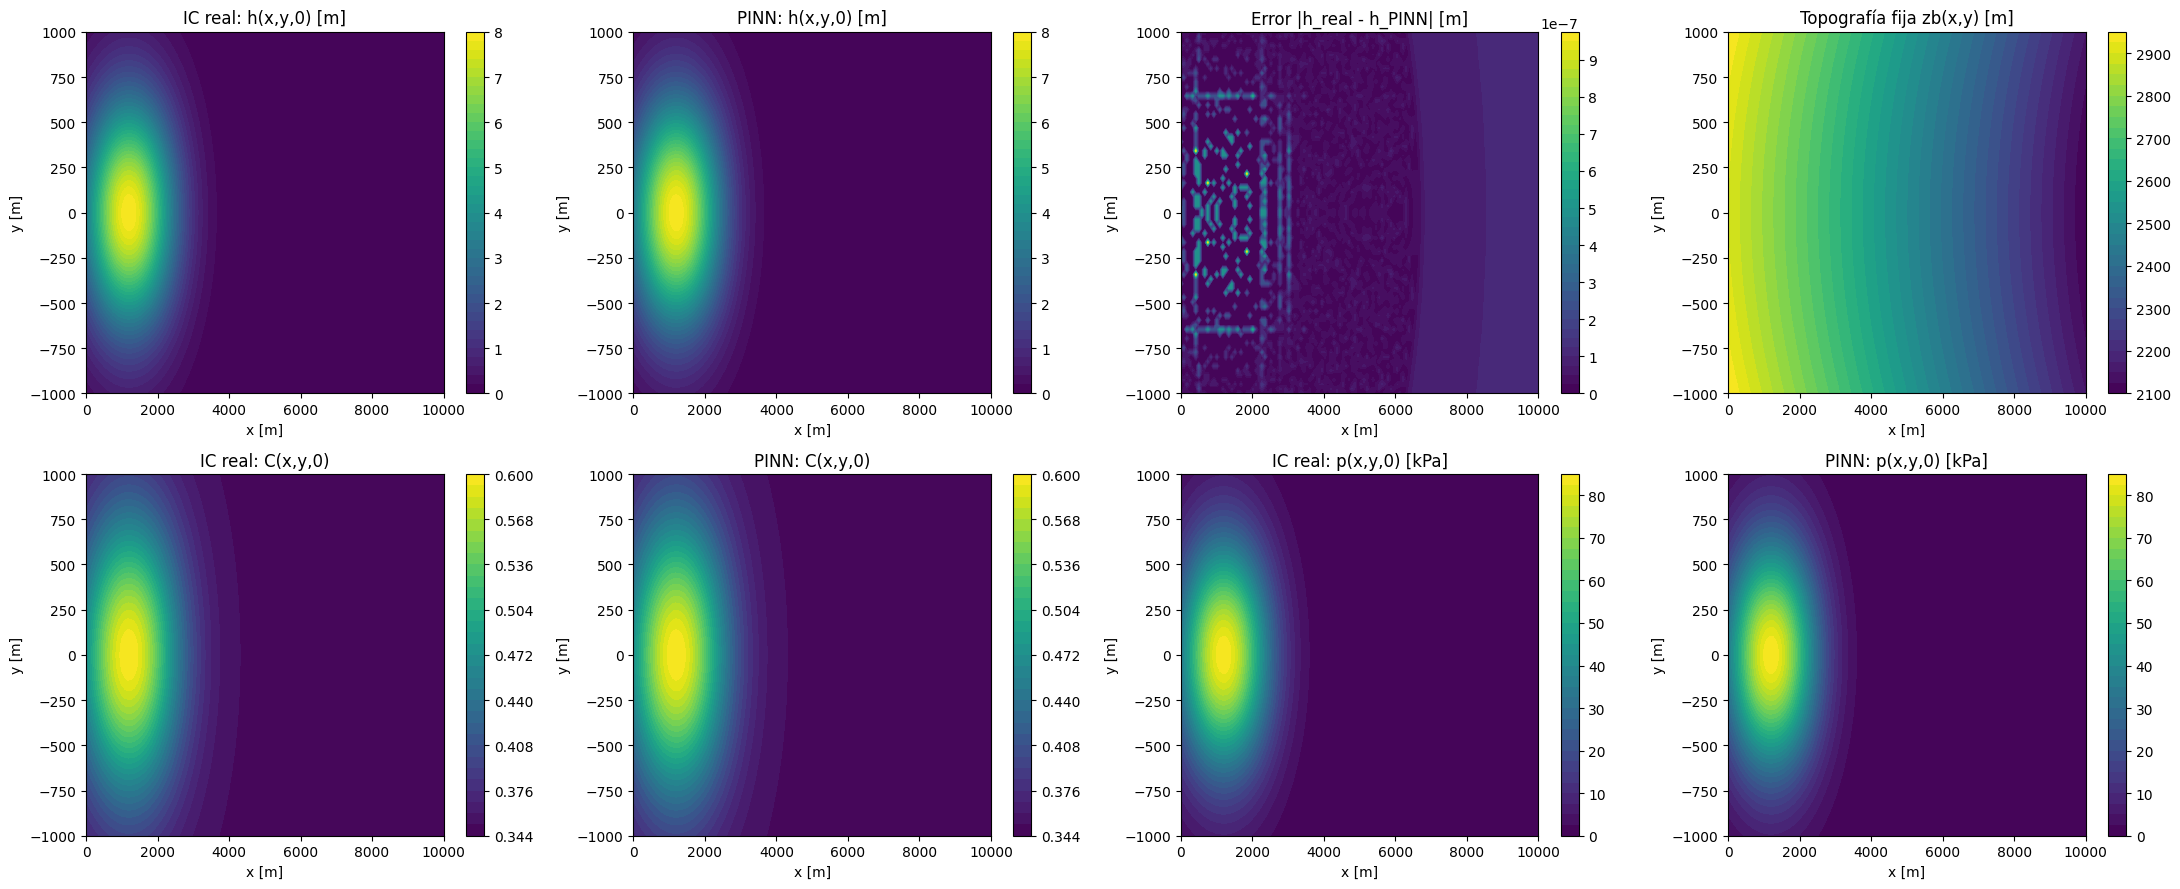

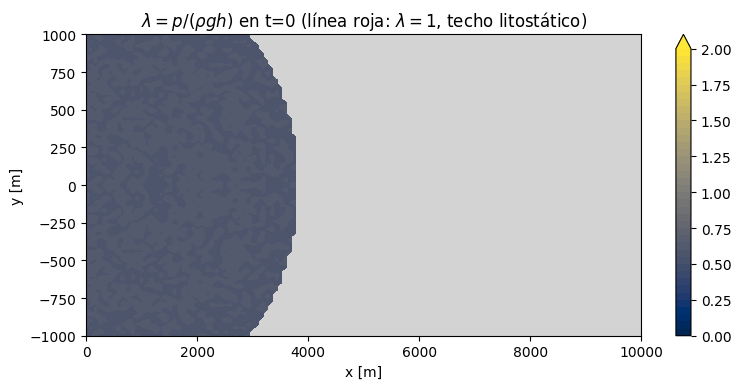

In [8]:
# ============================================================
# 11) VERIFICACIÓN DE CONDICIÓN INICIAL  (h, C y AHORA TAMBIÉN p)
# ============================================================
nx, ny = 120, 80
xg = np.linspace(x_min, x_max, nx).astype(np.float32)
yg = np.linspace(y_min, y_max, ny).astype(np.float32)
X, Y = np.meshgrid(xg, yg, indexing='xy')

Xf = X.reshape(-1, 1)
Yf = Y.reshape(-1, 1)
T0 = np.zeros_like(Xf, dtype=np.float32)

h_pred0, u_pred0, v_pred0, C_pred0, p_pred0 = predict_fields(
    tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf), tf.convert_to_tensor(T0))

h0_map_pred = h_pred0.numpy().reshape(ny, nx)
C0_map_pred = C_pred0.numpy().reshape(ny, nx)
p0_map_pred = p_pred0.numpy().reshape(ny, nx)
zb_map = zb0_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)

h0_map_true = ic_h_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)
C0_map_true = ic_C_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)
p0_map_true = ic_p_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)

lam0_map = p0_map_pred / np.maximum(rho_m * g * h0_map_pred, 1e-9)

# ------------------------------------------------------------
# CHEQUEO CUANTITATIVO. El ansatz hace EXACTAS las IC de h, u, v, C y p.
# p no tiene techo litostático: la fracción con lambda > 1 hay que vigilarla.
# ------------------------------------------------------------
err_h = np.abs(h0_map_true - h0_map_pred).max()
err_C = np.abs(C0_map_true - C0_map_pred).max()
err_p = np.abs(p0_map_true - p0_map_pred).max()
print("Error máximo de la condición inicial:")
print(f"  |h_real - h_PINN|_inf = {err_h:.3e} m      {'OK (ansatz duro)' if err_h < 1e-4 else '<-- REVISAR'}")
print(f"  |C_real - C_PINN|_inf = {err_C:.3e}        {'OK (ansatz duro)' if err_C < 1e-4 else '<-- REVISAR'}")
print(f"  |p_real - p_PINN|_inf = {err_p:.3e} Pa     "
      f"{'OK' if err_p < 1e3 else '<-- p NO TIENE ANSATZ DE IC: la condición inicial de presión de poros NO se está imponiendo'}")
print()
# lambda solo en la zona mojada: donde h ~ 1e-20 el cociente p/(rho g h) no tiene
# sentido físico (p queda en su piso numérico ~0.02 Pa y no afecta la fricción)
wet0 = h0_map_pred > 0.1
lam0_wet = lam0_map[wet0]
print(f"  lambda = p/(rho*g*h) en t=0 (zona mojada h>0.1 m):  min={lam0_wet.min():.3f}  "
      f"mediana={np.median(lam0_wet):.3f}  max={lam0_wet.max():.3f}")
print(f"  lambda deseado por ic_p_physical: {lambda_0:.3f} (uniforme)")
print(f"  fracción de la zona mojada con lambda > 1 (físicamente imposible): "
      f"{100.0*(lam0_wet > 1.0).mean():.1f}%")

# GATE DE MOVILIDAD: el lahar solo puede arrancar donde mu_eff < tan(theta)
zbx_g, zby_g = grad_zb_fixed(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf))
tan_map = np.sqrt(zbx_g.numpy()**2 + zby_g.numpy()**2).reshape(ny, nx)
mu0_map = mu_eff(C_pred0, p_pred0, h_pred0).numpy().reshape(ny, nx)
movil0 = 100.0 * (mu0_map[wet0] < tan_map[wet0]).mean()
print(f"\n  Zona mojada (h>0.1 m) con mu_eff < tan(theta) en t=0: {movil0:.1f}%   "
      f"(mu_eff mediano {np.median(mu0_map[wet0]):.3f} vs tan(theta) {np.median(tan_map[wet0]):.3f})")
if movil0 < 50.0:
    print("  *** Con estos parámetros la solución exacta es un lahar DETENIDO: subir lambda_0 ***")

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
panels = [
    (h0_map_true, "IC real: h(x,y,0) [m]", None),
    (h0_map_pred, "PINN: h(x,y,0) [m]", None),
    (np.abs(h0_map_true - h0_map_pred), "Error |h_real - h_PINN| [m]", None),
    (zb_map, "Topografía fija zb(x,y) [m]", None),
    (C0_map_true, "IC real: C(x,y,0)", None),
    (C0_map_pred, "PINN: C(x,y,0)", None),
    (p0_map_true / 1e3, "IC real: p(x,y,0) [kPa]", None),
    (p0_map_pred / 1e3, "PINN: p(x,y,0) [kPa]", None),
]
for ax, (Z, title, _) in zip(axes.ravel(), panels):
    cs = ax.contourf(X, Y, Z, levels=40)
    ax.set_title(title); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    plt.colorbar(cs, ax=ax)
plt.tight_layout(); plt.show()

# Mapa de lambda inicial: hace visible si p respeta el techo litostático
fig, ax = plt.subplots(figsize=(8, 4))
lam0_plot = np.ma.masked_where(~wet0, lam0_map)
ax.set_facecolor('lightgrey')
cs = ax.contourf(X, Y, np.clip(lam0_plot, 0, 2), levels=np.linspace(0, 2, 41),
                 cmap='cividis', extend='max')
ax.contour(X, Y, lam0_plot, levels=[1.0], colors='r', linewidths=2)
ax.set_title(r"$\lambda = p/(\rho g h)$ en t=0 (línea roja: $\lambda=1$, techo litostático)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
plt.colorbar(cs, ax=ax); plt.tight_layout(); plt.show()


 t [s]   X_c [m]   dXc/dt     U_c  |u|cuerpo   frente  lambda  %lam>1  %movil    masa   m+sal
     0    1351.2     0.82    0.00       0.00     3025   0.600     0.0    94.0   1.000   1.000
    50    1392.2     0.35    1.35       5.01     3025   0.557     0.0    89.4   0.871   0.871
   100    1385.9    -0.23    1.37       5.52     3025   0.556     0.0    88.4   0.882   0.882
   150    1369.2    -0.34    1.29       5.50     3025   0.557     0.0    86.7   0.896   0.896
   200    1352.2    -0.34    1.22       5.45     3025   0.557     0.0    84.6   0.910   0.910
   250    1335.5    -0.33    1.15       5.39     2941   0.557     0.0    82.6   0.924   0.924
   300    1319.3    -0.32    1.08       4.10     2941   0.557     0.0    81.0   0.938   0.938
   350    1303.7    -0.31    1.02       3.96     2941   0.557     0.0    80.0   0.951   0.951
   400    1288.7    -0.29    0.96       3.81     2941   0.557     0.0    79.0   0.963   0.963
   450    1274.2    -0.28    0.91       3.62     2941   0.55

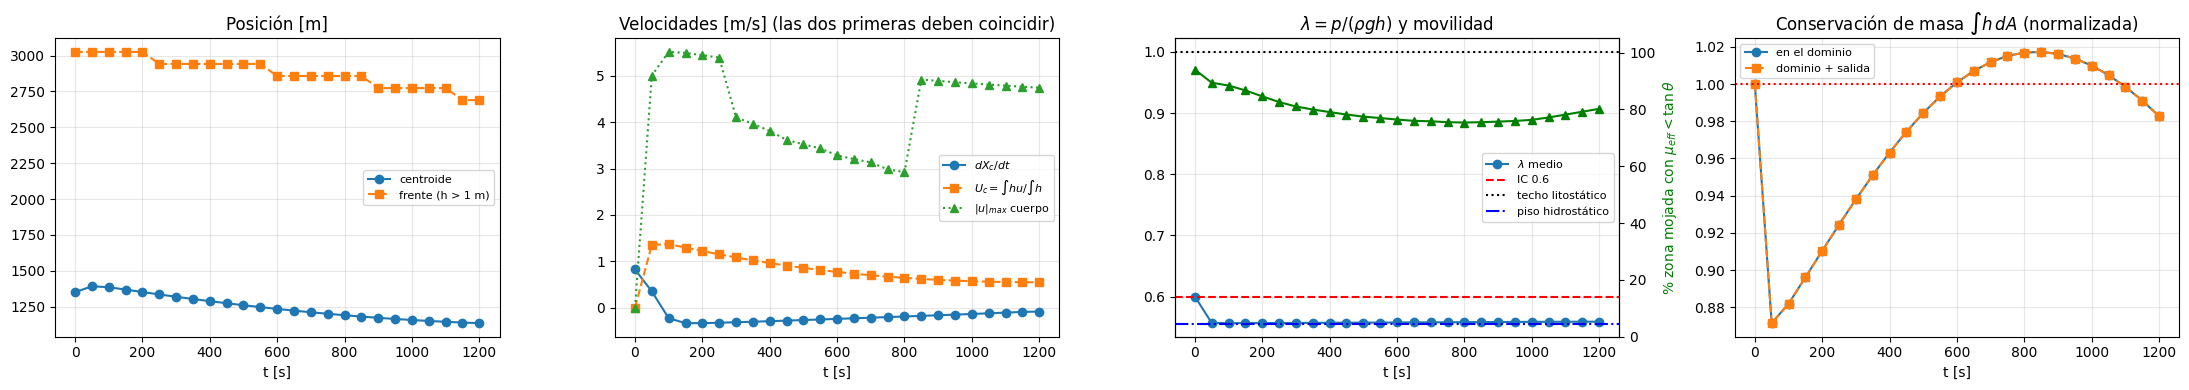

In [9]:
# ============================================================
# 12) DIAGNÓSTICO TEMPORAL: ¿se mueve el lahar y se conserva la masa?
# ============================================================
# Consistencia cinemática: si se conserva la masa y no hay flujo por las fronteras,
#   d/dt [ int x h dA ] = int h u dA   =>   dX_c/dt = U_c = (int h u dA)/(int h dA)
# Si dX_c/dt >> U_c, el centroide avanza porque la red CREA masa aguas abajo,
# no porque la transporte. Esa es la prueba de que el movimiento es físico.
t_check = np.linspace(0.0, Tmax, 25)
cell_area = (xg[1] - xg[0]) * (yg[1] - yg[0])
Xr = Xf.ravel()
zbx_g, zby_g = grad_zb_fixed(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf))
tan_f = np.sqrt(zbx_g.numpy()**2 + zby_g.numpy()**2).ravel()

cent, Uc, ucore, front, lam_c, lam_gt1, movil, mass, qout = [], [], [], [], [], [], [], [], []
for tv in t_check:
    Tf = np.full_like(Xf, tv, dtype=np.float32)
    hp, up, vp, Cp, pp = predict_fields(
        tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf), tf.convert_to_tensor(Tf))
    mu_f = mu_eff(Cp, pp, hp).numpy().ravel()
    hh = hp.numpy().ravel(); uu = up.numpy().ravel()
    vv = vp.numpy().ravel(); pz = pp.numpy().ravel()
    w = np.maximum(hh, 0.0)
    cent.append(float((Xr * w).sum() / max(w.sum(), 1e-12)))
    Uc.append(float((w * uu).sum() / max(w.sum(), 1e-12)))          # velocidad media ponderada por h
    core = hh > 1.0                                                  # cuerpo del lahar (no la película delgada)
    ucore.append(float(np.sqrt(uu[core]**2 + vv[core]**2).max()) if core.any() else 0.0)
    front.append(float(Xr[core].max()) if core.any() else np.nan)    # frente del cuerpo (h > 1 m)
    wet = hh > 0.1
    lam = pz[wet] / (rho_m * g * hh[wet])
    lam_c.append(float(lam.mean()) if wet.any() else np.nan)
    lam_gt1.append(100.0 * float((lam > 1.0).mean()) if wet.any() else np.nan)
    movil.append(100.0 * float((mu_f[wet] < tan_f[wet]).mean()) if wet.any() else np.nan)
    mass.append(float(w.sum() * cell_area))
    # caudal que sale por x = Lx (se integra en el tiempo más abajo)
    hq, uq, _, _, _ = predict_fields(tf.constant(np.full((ny, 1), x_max, np.float32)),
                                     tf.constant(yg.reshape(-1, 1)), tf.constant(np.full((ny, 1), tv, np.float32)))
    qout.append(float((hq.numpy() * uq.numpy()).sum() * (yg[1] - yg[0])))

dXc = np.gradient(np.array(cent), t_check)                           # velocidad del centroide
# volumen acumulado que salió por x = Lx: masa + salida debe ser constante
vout = np.concatenate([[0.0], np.cumsum(0.5 * (np.array(qout[1:]) + np.array(qout[:-1])) * np.diff(t_check))])
bal = (np.array(mass) + vout) / mass[0]
print(f"{'t [s]':>6} {'X_c [m]':>9} {'dXc/dt':>8} {'U_c':>7} {'|u|cuerpo':>10} {'frente':>8} "
      f"{'lambda':>7} {'%lam>1':>7} {'%movil':>7} {'masa':>7} {'m+sal':>7}")
for k, tv in enumerate(t_check):
    print(f"{tv:6.0f} {cent[k]:9.1f} {dXc[k]:8.2f} {Uc[k]:7.2f} {ucore[k]:10.2f} {front[k]:8.0f} "
          f"{lam_c[k]:7.3f} {lam_gt1[k]:7.1f} {movil[k]:7.1f} {mass[k]/mass[0]:7.3f} {bal[k]:7.3f}")
print("  dXc/dt, U_c, |u|cuerpo en m/s | frente = x máx. con h > 1 m | %movil = zona mojada con mu_eff < tan(theta)")
print("  m+sal = (volumen en el dominio + volumen que salió por x = Lx)/V0: debe ser 1")
print("  Nota: cuando el lahar sale por x = Lx, X_c y U_c dejan de ser comparables (la masa se va del dominio).")

desp = cent[-1] - cent[0]
incons = np.abs(dXc - np.array(Uc)).mean()
print(f"\n>>> Desplazamiento del centroide en {Tmax:.0f} s: {desp:+.1f} m (velocidad media {desp/Tmax:+.2f} m/s)")
print(f">>> Frente del cuerpo: {front[0]:.0f} m -> {front[-1]:.0f} m")
print(f">>> Masa en el dominio: {mass[-1]/mass[0]:.4f} | salió por x=Lx: {vout[-1]/mass[0]:.4f} | balance: {bal[-1]:.4f} (debe ser 1)")
print(f">>> lambda: {lam_c[0]:.3f} (t=0) -> {lam_c[-1]:.3f} (t={Tmax:.0f});  máx. % con lambda>1: {np.nanmax(lam_gt1):.1f}%")
print(f">>> |dXc/dt - U_c| medio = {incons:.2f} m/s  (debe ser ~0 si el transporte es físico)")
if desp < 50.0:
    print("\n*** EL FLUJO SIGUE BLOQUEADO por fricción. ***")
if np.abs(bal - 1.0).max() > 0.05:
    print("*** LA MASA NO SE CONSERVA (balance con la salida por x = Lx fuera de ±5%). ***")
if incons > 0.5:
    print("*** El centroide NO se mueve con la velocidad del flujo: masa creada/destruida, no transportada. ***")
if np.nanmax(lam_gt1) > 1.0:
    print("*** Hay zona mojada con lambda > 1: la red está apagando la fricción con presión imposible. ***")

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
axes[0].plot(t_check, cent, 'o-', label='centroide')
axes[0].plot(t_check, front, 's--', label='frente (h > 1 m)')
axes[0].set_title("Posición [m]"); axes[0].legend(fontsize=8)
axes[1].plot(t_check, dXc, 'o-', label=r'$dX_c/dt$')
axes[1].plot(t_check, Uc, 's--', label=r'$U_c=\int hu/\int h$')
axes[1].plot(t_check, ucore, '^:', label=r'$|u|_{max}$ cuerpo')
axes[1].set_title("Velocidades [m/s] (las dos primeras deben coincidir)"); axes[1].legend(fontsize=8)
axes[2].plot(t_check, lam_c, 'o-', label=r'$\lambda$ medio')
axes[2].axhline(lambda_0, ls='--', c='r', label=f'IC {lambda_0}')
axes[2].axhline(1.0, ls=':', c='k', label='techo litostático')
axes[2].axhline(lambda_hydro, ls='-.', c='b', label='piso hidrostático')
ax2b = axes[2].twinx(); ax2b.plot(t_check, movil, 'g^-', label='% móvil'); ax2b.set_ylim(0, 105)
ax2b.set_ylabel(r'% zona mojada con $\mu_{eff}<\tan\theta$', color='g')
axes[2].set_title(r"$\lambda = p/(\rho g h)$ y movilidad"); axes[2].legend(fontsize=8, loc='center right')
axes[3].plot(t_check, np.array(mass)/mass[0], 'o-', label='en el dominio')
axes[3].plot(t_check, bal, 's--', label='dominio + salida')
axes[3].axhline(1.0, ls=':', c='r'); axes[3].legend(fontsize=8)
axes[3].set_title(r"Conservación de masa $\int h\,dA$ (normalizada)")
for a in axes: a.set_xlabel("t [s]"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [10]:
# ============================================================
# 13) ANIMACIÓN: h, |u|, C, lambda
# ============================================================
import matplotlib.animation as animation
from IPython.display import HTML

# OJO: ya no hay condición de Neumann sobre C (loss_C_flux fue eliminado y
# kappa_C = 0). La única BC activa es h = 0 tipo Dirichlet en y = +-Ly/2.
etiqueta = f"5PDE_chi{chi_p:.2f}_kC{kappa_C:.1f}_T{Tmax:.0f}"
num_frames = 60
t_values = np.linspace(0.0, Tmax, num_frames)

# Niveles FIJOS. contourf con levels=<int> recalcula los niveles frame a frame
# a partir del rango de los datos e IGNORA vmin/vmax para elegirlos, así que
# la escala de color cambiaba en cada cuadro y la animación era engañosa.
lv_h   = np.linspace(0.0, 8.0, 41)
lv_u   = np.linspace(0.0, 20.0, 41)
lv_C   = np.linspace(0.2, Cmax, 41)
lv_lam = np.linspace(0.0, 1.5, 41)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle(f"Lahar 5-EDP — {Tmax:.0f} s — "
             rf"$\chi_p$={chi_p}, $\kappa_C$={kappa_C}, $\tau_p$={tau_p:.0f} s")

def update(frame):
    for a in axes.ravel(): a.clear()
    tv = t_values[frame]
    Tf = np.full_like(Xf, tv, dtype=np.float32)
    hp, up, vp, Cp, pp = predict_fields(
        tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf), tf.convert_to_tensor(Tf))

    h_map = hp.numpy().reshape(ny, nx)
    U_map = np.sqrt(up.numpy()**2 + vp.numpy()**2).reshape(ny, nx)
    C_map = Cp.numpy().reshape(ny, nx)
    lam_map = (pp.numpy() / np.maximum(rho_m * g * hp.numpy(), 1e-9)).reshape(ny, nx)

    # Máscara por ESPESOR, no por concentración: C vale ~0.35 de fondo en todo
    # el dominio, así que la máscara antigua (C < 0.01) no se activaba nunca.
    dry = h_map < 0.05
    U_m, C_m, lam_m = (np.ma.masked_where(dry, Z) for Z in (U_map, C_map, lam_map))

    for a in axes.ravel(): a.set_facecolor('lightgrey')
    axes[0, 0].contourf(X, Y, h_map, levels=lv_h, cmap='viridis', extend='max')
    axes[0, 0].set_title(f"Espesor h   t={tv:.0f} s   [m]")
    axes[0, 1].contourf(X, Y, U_m, levels=lv_u, cmap='magma', extend='max')
    axes[0, 1].set_title(f"Velocidad |u|   t={tv:.0f} s   [m/s]")
    axes[1, 0].contourf(X, Y, C_m, levels=lv_C, cmap='plasma', extend='both')
    axes[1, 0].set_title(f"Concentración C   t={tv:.0f} s")
    axes[1, 1].contourf(X, Y, lam_m, levels=lv_lam, cmap='cividis', extend='max')
    axes[1, 1].contour(X, Y, np.ma.masked_where(dry, lam_map), levels=[1.0],
                       colors='r', linewidths=1.5)
    axes[1, 1].set_title(rf"$\lambda = p/(\rho g h)$   t={tv:.0f} s   (rojo: $\lambda=1$)")
    for a in axes.ravel():
        a.set_xlabel("x [m]"); a.set_ylabel("y [m]")

print("Generando animación, por favor espera...")
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=100)
aniname = f"Prediccion {etiqueta}.gif"
ani.save(aniname, writer='pillow', fps=10)
print(f"GIF guardado como '{aniname}'")
plt.close()
display(HTML(ani.to_jshtml()))


Generando animación, por favor espera...
GIF guardado como 'Prediccion 5PDE_chi0.80_kC0.0_T1200.gif'
